## Convoplution Operations , Filters, and Feature Maps
. What is convolution operation
    . Mathematical operation where a small matrix (kernel or filter) slides over the input image to extract features like edges textures or patterns
    . Key Concepts
        . Kernel(Filter)
            . A small matrix 3x3 used to extract features
            . Each element of the kernel is a weight learned during training
        . Feature Map
            . Output of conv opers
            . Highlights specific patterns detected by the filters
        . Channels
            . For RGB images,conv process each color channel separately and combines results
### Concepts of Kernel Size , Stride and padding
    .  kernel size
        . THe dimensions of the filter eg 3x3, 5x5
        . Smaller kernel capture fine details
        . Larger kernels detect broader features
    . Stride
        . Defines the steps size of the filter as it slides across the input
        . Larger Strides : Reduce the feature map size , improving computatuion efficiencty
        . Smaller Strides : retain mode detail but increase computation 
    . Padding
        . Adds extra pixels arouind the input to control the sixe of the output
        . valid padding : No Padding : the feature map shrinks
        . Same padding : Adds enogh padding to keep the output sizxe equalt to the input size 
### Visualizing How conv extractws features
    . Edge Detection
        . Kernesls like Sobel or Prewitt highlight edges in images
    . Feature Extraction
        . initial layeers focus on edges ; deeper layers capture abstract patterns
        

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import convolve

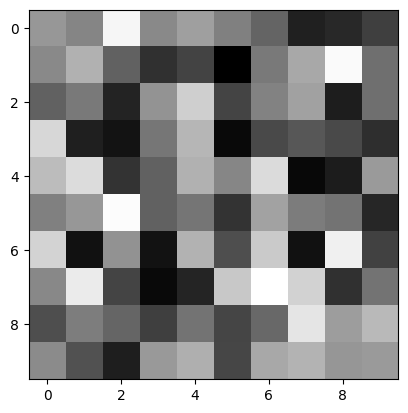

In [2]:
# Load a sample gray scale image

image = np.random.rand(10,10)
plt.imshow(image, cmap='gray')

In [ ]:
# Define convolution kernels
edge_detection_kernel = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1],
])

blue_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1],
]) / 9 



In [4]:
# Apply Convs
edge_detected_image = convolve(image, edge_detection_kernel)
blurred_image = convolve(image, blue_kernel)

Text(0.5, 1.0, 'Blurred Image')

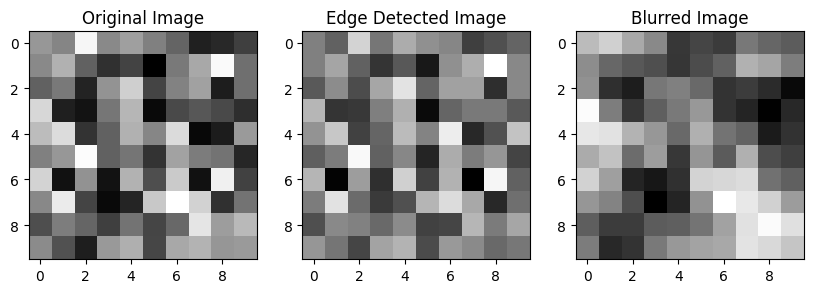

In [7]:
# plt.imshow(edge_detected_image, cmap='gray')
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(edge_detected_image, cmap='gray')
axes[1].set_title('Edge Detected Image')
axes[2].imshow(blurred_image, cmap='gray')
axes[2].set_title('Blurred Image')
# plt.imshow(blurred_image, cmap='gray')

In [8]:
import tensorflow as tf

In [9]:
# create sample input tensor (batcxh_size, height, width, channels)
image_tensor = tf.random.normal([1, 10, 10, 1])

# define convolutional layer
conv_layer = tf.keras.layers.Conv2D(filters=1, kernel_size=(3, 3), padding='same', strides=(1, 1),)

# Apply convolutional layer to the input tensor
output_tensor = conv_layer(image_tensor) 

Input Tensor Shape: (1, 10, 10, 1)
Output Tensor Shape: (1, 10, 10, 1)


Text(0.5, 1.0, 'Output Tensor after Conv2D')

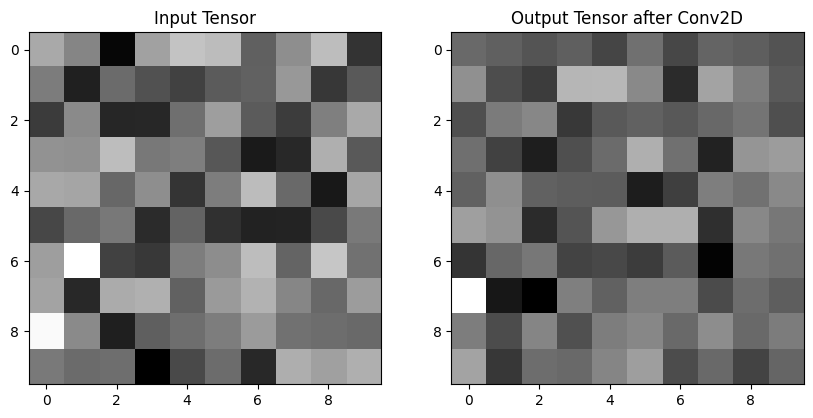

In [10]:
print("Input Tensor Shape:", image_tensor.shape)
print("Output Tensor Shape:", output_tensor.shape)
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(image_tensor[0,:,:,0], cmap='gray')
axes[0].set_title('Input Tensor')
axes[1].imshow(output_tensor[0,:,:,0], cmap='gray')
axes[1].set_title('Output Tensor after Conv2D')

In [11]:
import torch.nn as nn
import torch


In [ ]:
# Create a sample input tensor (batch_size, channels, height, width)
image_tensor = torch.randn(1,1,10,10)  # Batch size of 1, 1 channel, 10x10 image

# Conv layer
conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1)

# Apply convolutional layer to the input tensor
output_tensor = conv_layer(image_tensor)



Input Tensor Shape: torch.Size([1, 1, 10, 10])
Output Tensor Shape: torch.Size([1, 1, 10, 10])


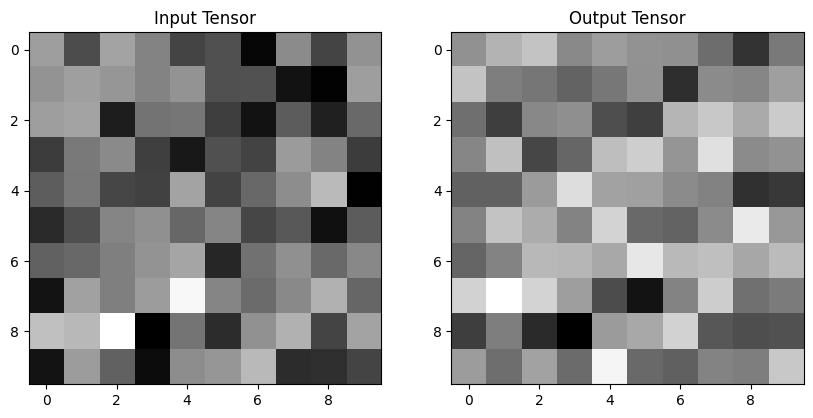

In [23]:
print("Input Tensor Shape:", image_tensor.shape)
print("Output Tensor Shape:", output_tensor.shape)
ig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    image_tensor[0,0].detach().numpy(),
    cmap='gray'
)
axes[0].set_title('Input Tensor')

axes[1].imshow(
    output_tensor[0,0].detach().numpy(),
    cmap='gray'
)
axes[1].set_title('Output Tensor')

plt.show()   